# WellCo Uplift Modeling — EDA v2: Treatment Effect Heterogeneity

This notebook focuses on the **conditional average treatment effect (CATE)** — how the effect of outreach varies across member subgroups.  
It does **not** repeat the Phase 1 EDA; instead it asks: **who benefits most from outreach?**

Key questions:
1. Is the treatment assignment sufficiently random (covariate balance check)?
2. Which subgroups show the highest outreach-driven churn reduction?
3. Which features are most predictive of *heterogeneous* treatment response?

**Input:** `train_features.parquet` (includes `churn` and `outreach` columns)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

train = pd.read_parquet('train_features.parquet')

treated = train[train['outreach'] == 1]
control = train[train['outreach'] == 0]

ATE = control['churn'].mean() - treated['churn'].mean()

print(f"Members:  {len(train):,}")
print(f"Treated:  {len(treated):,} ({len(treated)/len(train):.1%})")
print(f"Control:  {len(control):,} ({len(control)/len(train):.1%})")
print(f"")
print(f"Overall churn rate:  {train['churn'].mean():.3f}")
print(f"Control churn rate:  {control['churn'].mean():.3f}")
print(f"Treated churn rate:  {treated['churn'].mean():.3f}")
print(f"")
print(f"ATE (churn reduction from outreach): {ATE:.4f} ({ATE*100:.2f} pp)")

Members:  10,000
Treated:  3,984 (39.8%)
Control:  6,016 (60.2%)

Overall churn rate:  0.202
Control churn rate:  0.207
Treated churn rate:  0.194

ATE (churn reduction from outreach): 0.0134 (1.34 pp)


## 1. Randomization Check

Uplift models require that treatment is (at least approximately) randomly assigned.  
We check **standardized mean difference (SMD)** for each feature: SMD < 0.1 indicates good balance.

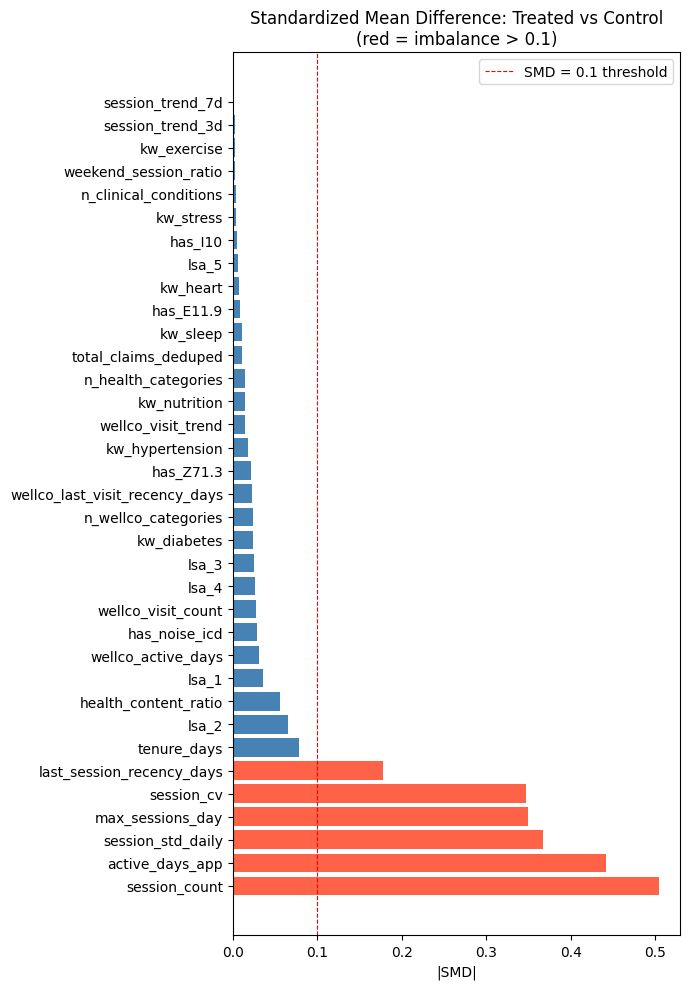

Max SMD: 0.5043  (features > 0.1: 6)
session_count                0.5043
active_days_app              0.4414
session_std_daily            0.3679
max_sessions_day             0.3491
session_cv                   0.3470
last_session_recency_days    0.1773
tenure_days                  0.0785
lsa_2                        0.0657
health_content_ratio         0.0557
lsa_1                        0.0355
dtype: float64


In [2]:
FEAT_COLS = [c for c in train.columns if c not in ['member_id', 'churn', 'outreach']]

smd_vals = {}
for feat in FEAT_COLS:
    mu_t = treated[feat].mean()
    mu_c = control[feat].mean()
    sd_pooled = np.sqrt((treated[feat].var() + control[feat].var()) / 2 + 1e-12)
    smd_vals[feat] = abs(mu_t - mu_c) / sd_pooled

smd_df = pd.Series(smd_vals).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['tomato' if v > 0.1 else 'steelblue' for v in smd_df]
ax.barh(smd_df.index, smd_df.values, color=colors)
ax.axvline(0.1, color='red', linestyle='--', linewidth=0.8, label='SMD = 0.1 threshold')
ax.set_title('Standardized Mean Difference: Treated vs Control\n(red = imbalance > 0.1)')
ax.set_xlabel('|SMD|')
ax.legend()
plt.tight_layout()
plt.savefig('eda_v2_smd.png', dpi=120)
plt.show()

print(f"Max SMD: {smd_df.max():.4f}  (features > 0.1: {(smd_df > 0.1).sum()})")
print(smd_df.head(10).round(4))

## 2. CATE by Feature Quartile

For each key feature, we split members into quartiles and compute:
- Control churn rate
- Treated churn rate  
- **Uplift** = control rate − treated rate

This reveals **where** the treatment effect is largest — i.e., which members are most responsive to outreach.

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = d.groupby(['q', 'outreach']).agg(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_bounds = d.groupby('q')[feature].agg(['min', 'max'])
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

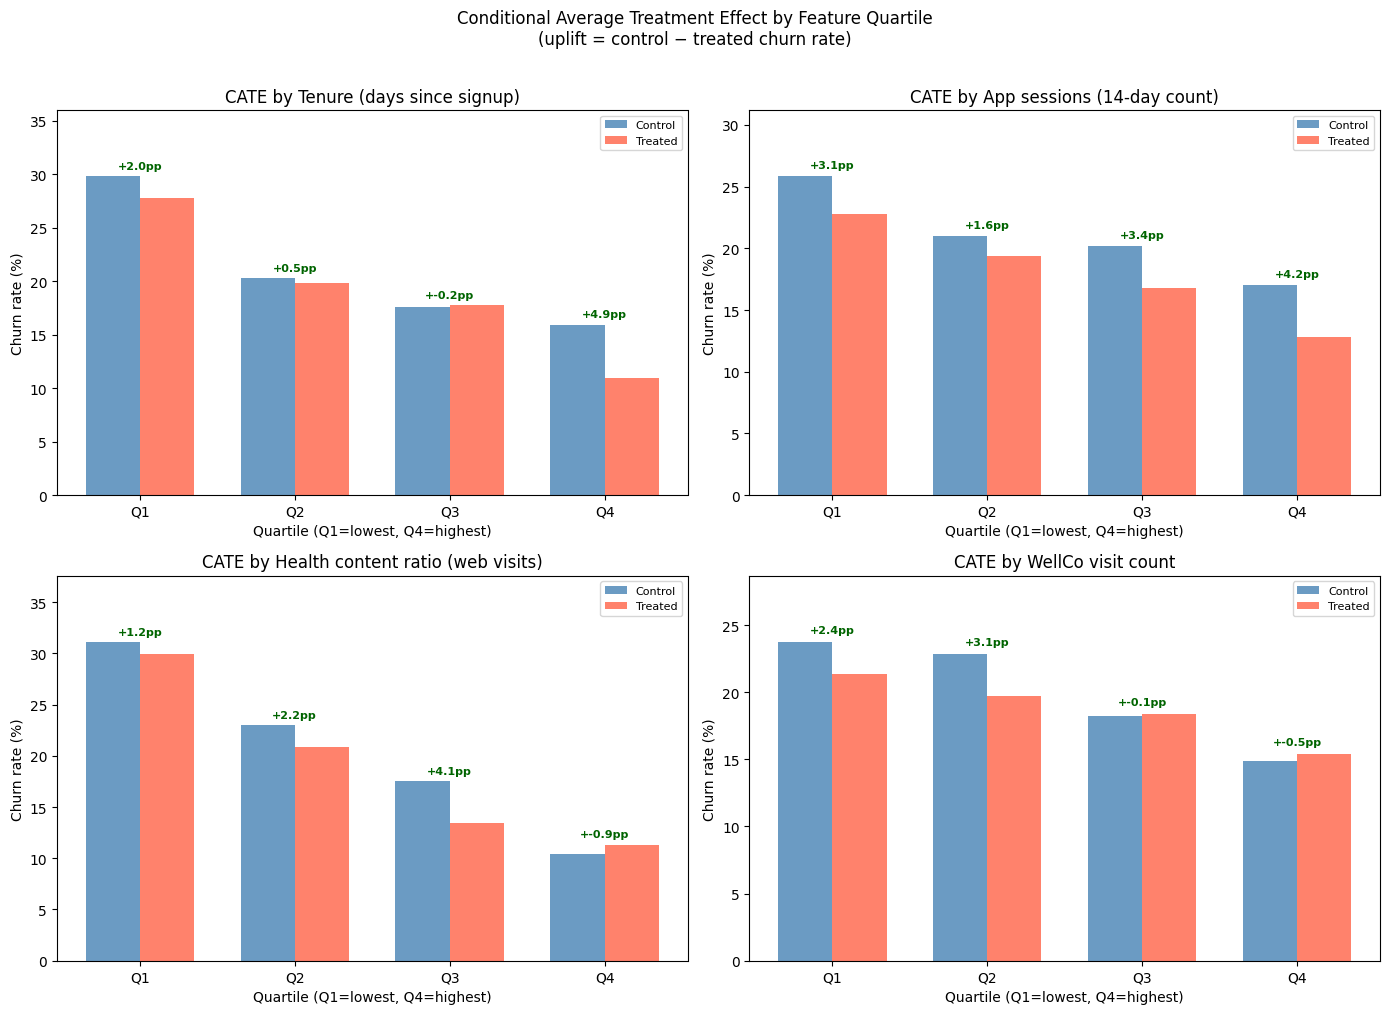


--- Tenure (days since signup) ---
    control_churn  treated_churn  uplift_pp
q                                          
Q1          0.298          0.278      2.001
Q2          0.203          0.198      0.487
Q3          0.176          0.178     -0.213
Q4          0.159          0.110      4.926

--- App sessions (14-day count) ---
    control_churn  treated_churn  uplift_pp
q                                          
Q1          0.258          0.228      3.085
Q2          0.210          0.194      1.577
Q3          0.202          0.168      3.402
Q4          0.170          0.128      4.157

--- Health content ratio (web visits) ---
    control_churn  treated_churn  uplift_pp
q                                          
Q1          0.311          0.299      1.173
Q2          0.230          0.208      2.192
Q3          0.175          0.134      4.081
Q4          0.104          0.113     -0.921

--- WellCo visit count ---
    control_churn  treated_churn  uplift_pp
q                   

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = d.groupby(['q', 'outreach']).agg(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_bounds = d.groupby('q')[feature].agg(['min', 'max'])
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

In [3]:
def cate_by_quartile(df, feature, n_q=4):
    """Returns a table of churn rates and uplift by quartile."""
    d = df.copy()
    d['q'] = pd.qcut(d[feature], n_q, labels=[f'Q{i+1}' for i in range(n_q)], duplicates='drop')
    
    agg = d.groupby(['q', 'outreach']).agg(
        n=('churn', 'count'),
        churn_rate=('churn', 'mean')
    ).reset_index()
    
    piv = agg.pivot(index='q', columns='outreach', values='churn_rate')
    piv.columns = ['control_churn', 'treated_churn']
    piv['uplift_pp'] = (piv['control_churn'] - piv['treated_churn']) * 100
    
    # Add quartile boundaries for context
    q_bounds = d.groupby('q')[feature].agg(['min', 'max'])
    piv = piv.join(q_bounds)
    return piv


KEY_FEATURES = [
    ('tenure_days',           'Tenure (days since signup)'),
    ('session_count',         'App sessions (14-day count)'),
    ('health_content_ratio',  'Health content ratio (web visits)'),
    ('wellco_visit_count',    'WellCo visit count'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, KEY_FEATURES):
    cate = cate_by_quartile(train, feat)
    
    x = np.arange(len(cate))
    width = 0.35
    bars_c = ax.bar(x - width/2, cate['control_churn'] * 100, width,
                    label='Control', color='steelblue', alpha=0.8)
    bars_t = ax.bar(x + width/2, cate['treated_churn'] * 100, width,
                    label='Treated', color='tomato', alpha=0.8)
    
    # Annotate uplift
    for i, (q, row) in enumerate(cate.iterrows()):
        ax.text(i, max(row['control_churn'], row['treated_churn']) * 100 + 0.5,
                f"+{row['uplift_pp']:.1f}pp",
                ha='center', va='bottom', fontsize=8, color='darkgreen', fontweight='bold')
    
    ax.set_title(f'CATE by {label}')
    ax.set_xlabel('Quartile (Q1=lowest, Q4=highest)')
    ax.set_ylabel('Churn rate (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(cate.index)
    ax.legend(fontsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.suptitle('Conditional Average Treatment Effect by Feature Quartile\n(uplift = control − treated churn rate)', y=1.01)
plt.tight_layout()
plt.savefig('eda_v2_cate_quartile.png', dpi=120, bbox_inches='tight')
plt.show()

for feat, label in KEY_FEATURES:
    print(f"\n--- {label} ---")
    print(cate_by_quartile(train, feat)[['control_churn','treated_churn','uplift_pp']].round(3))

## 3. CATE by Clinical Condition Profile

Clinical conditions (diabetes E11.9, hypertension I10, nutrition Z71.3) may moderate treatment response —  
members managing chronic conditions may be more engaged and responsive to health outreach.

In [4]:
def churn_by_group(df, group_col):
    return df.groupby([group_col, 'outreach']).agg(
        n=('churn', 'count'),
        churn_rate=('churn', 'mean')
    ).reset_index()

clinical_features = {
    'n_clinical_conditions': 'Number of clinical conditions',
    'has_E11.9':  'Has diabetes (E11.9)',
    'has_I10':    'Has hypertension (I10)',
    'has_Z71.3':  'Has nutrition counseling (Z71.3)',
}

rows = []
for col, label in clinical_features.items():
    for val in sorted(train[col].unique()):
        sub = train[train[col] == val]
        t_rate = sub[sub['outreach']==1]['churn'].mean()
        c_rate = sub[sub['outreach']==0]['churn'].mean()
        rows.append({
            'Feature': label, 'Value': val,
            'n': len(sub),
            'control_churn': c_rate,
            'treated_churn': t_rate,
            'uplift_pp': (c_rate - t_rate) * 100
        })

clin_df = pd.DataFrame(rows)
print(clin_df.round(4).to_string(index=False))

                         Feature  Value    n  control_churn  treated_churn  uplift_pp
   Number of clinical conditions    0.0  752         0.2422         0.2484    -0.6214
   Number of clinical conditions    1.0 2954         0.2431         0.1936     4.9487
   Number of clinical conditions    2.0 4173         0.1973         0.1970     0.0315
   Number of clinical conditions    3.0 2121         0.1648         0.1688    -0.4003
            Has diabetes (E11.9)    0.0 4120         0.2229         0.1979     2.4911
            Has diabetes (E11.9)    1.0 5880         0.1967         0.1913     0.5478
          Has hypertension (I10)    0.0 4113         0.2330         0.2024     3.0551
          Has hypertension (I10)    1.0 5887         0.1897         0.1881     0.1570
Has nutrition counseling (Z71.3)    0.0 4104         0.2269         0.2149     1.2038
Has nutrition counseling (Z71.3)    1.0 5896         0.1936         0.1799     1.3775


## 4. Feature Correlation with Proxy Uplift

We compute a **rough proxy uplift score** per member using a simple propensity-adjusted approach:  
Since treatment is near-random, we can estimate each member's individual-level uplift as:

```
proxy_uplift = (2W - 1) * Y  where W = treatment, Y = churn outcome
```

This is the **Transformed Outcome** estimator (Athey & Imbens). Under random treatment,  
E[proxy_uplift | X] = CATE(X). Correlating features with proxy_uplift identifies which features  
predict heterogeneous treatment response.

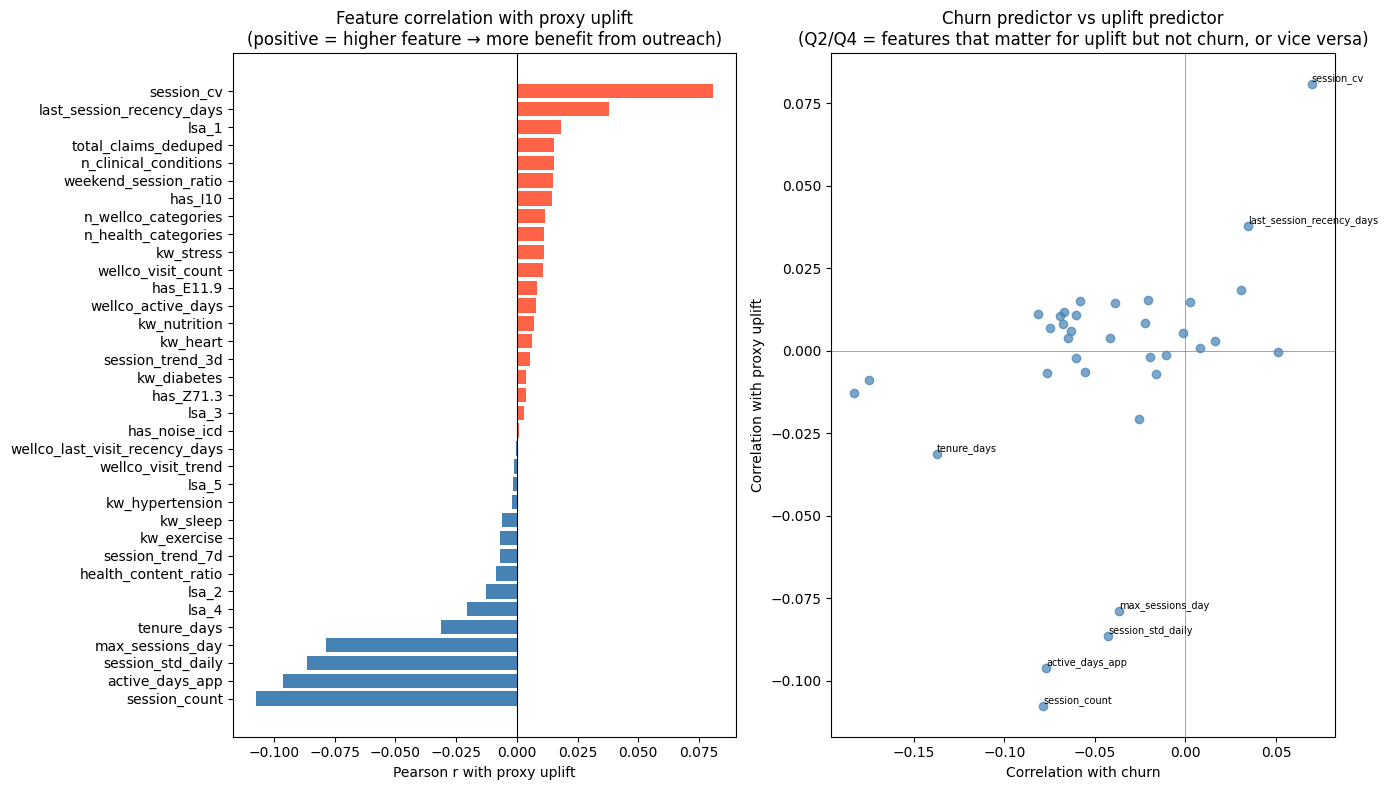

Top features by |correlation with proxy uplift|:
session_count                0.1075
active_days_app              0.0962
session_std_daily            0.0863
session_cv                   0.0808
max_sessions_day             0.0787
last_session_recency_days    0.0377
tenure_days                  0.0314
lsa_4                        0.0205
lsa_1                        0.0184
total_claims_deduped         0.0153
dtype: float64


In [5]:
# Transformed outcome: (2W-1)*Y under random treatment approximates CATE
# For slightly imbalanced treatment, use propensity weighting
p_treat = train['outreach'].mean()
train['proxy_uplift'] = np.where(
    train['outreach'] == 1,
    train['churn'] / p_treat,
    -train['churn'] / (1 - p_treat)
)

# Correlation of each feature with proxy uplift
uplift_corr = {}
for feat in FEAT_COLS:
    r, p = stats.pearsonr(train[feat], train['proxy_uplift'])
    uplift_corr[feat] = r

uplift_corr_s = pd.Series(uplift_corr).sort_values()

# Also compare: correlation with churn vs correlation with uplift
churn_corr = train[FEAT_COLS].corrwith(train['churn'])

comparison = pd.DataFrame({
    'corr_with_churn':       churn_corr,
    'corr_with_uplift':      uplift_corr_s,
}).sort_values('corr_with_uplift')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: feature correlation with proxy uplift
colors = ['tomato' if v > 0 else 'steelblue' for v in uplift_corr_s]
axes[0].barh(uplift_corr_s.index, uplift_corr_s.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature correlation with proxy uplift\n(positive = higher feature → more benefit from outreach)')
axes[0].set_xlabel('Pearson r with proxy uplift')

# Right: scatter — churn correlation vs uplift correlation
axes[1].scatter(comparison['corr_with_churn'], comparison['corr_with_uplift'],
                alpha=0.7, color='steelblue')
for feat, row in comparison.iterrows():
    if abs(row['corr_with_uplift']) > 0.03:
        axes[1].annotate(feat, (row['corr_with_churn'], row['corr_with_uplift']),
                         fontsize=7, ha='left', va='bottom')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel('Correlation with churn')
axes[1].set_ylabel('Correlation with proxy uplift')
axes[1].set_title('Churn predictor vs uplift predictor\n(Q2/Q4 = features that matter for uplift but not churn, or vice versa)')

plt.tight_layout()
plt.savefig('eda_v2_uplift_corr.png', dpi=120)
plt.show()

print("Top features by |correlation with proxy uplift|:")
print(uplift_corr_s.abs().sort_values(ascending=False).head(10).round(4))

## 5. Two-Way CATE: Tenure × Engagement

The two strongest predictors of churn (tenure_days and session_count) may jointly determine uplift.  
A heatmap of treatment effect across these two dimensions guides prioritization strategy.

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/3149104995.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_stats = d.groupby(['tenure_q', 'session_q', 'outreach']).agg(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/3149104995.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = cell_stats.pivot_table(index='tenure_q', columns=['session_q', 'outreach'],


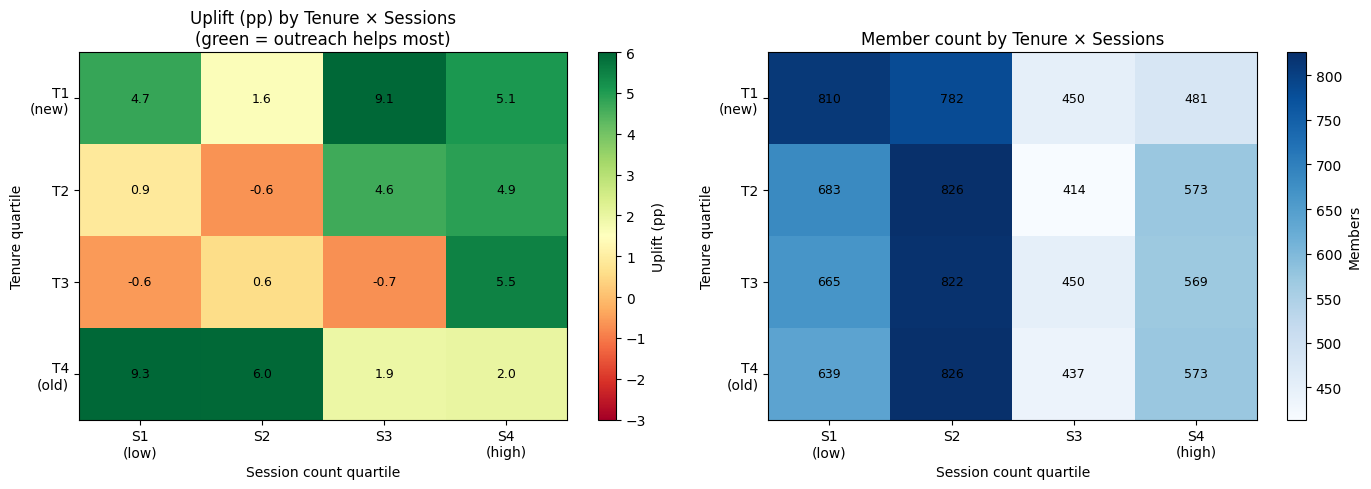


Uplift heatmap (pp) — Tenure × Sessions:
      S1    S2    S3    S4
T1  4.74  1.57  9.15  5.07
T2  0.89 -0.65  4.64  4.90
T3 -0.57  0.58 -0.69  5.48
T4  9.32  5.96  1.93  2.01


In [6]:
d = train.copy()
d['tenure_q']  = pd.qcut(d['tenure_days'],  4, labels=['T1','T2','T3','T4'])
d['session_q'] = pd.qcut(d['session_count'], 4, labels=['S1','S2','S3','S4'])

cell_stats = d.groupby(['tenure_q', 'session_q', 'outreach']).agg(
    n=('churn','count'), churn_rate=('churn','mean')
).reset_index()

piv = cell_stats.pivot_table(index='tenure_q', columns=['session_q', 'outreach'],
                             values='churn_rate')

uplift_heatmap = pd.DataFrame(index=['T1','T2','T3','T4'],
                               columns=['S1','S2','S3','S4'], dtype=float)
n_heatmap     = pd.DataFrame(index=['T1','T2','T3','T4'],
                               columns=['S1','S2','S3','S4'], dtype=float)

for tq in ['T1','T2','T3','T4']:
    for sq in ['S1','S2','S3','S4']:
        sub = d[(d['tenure_q']==tq) & (d['session_q']==sq)]
        t_ = sub[sub['outreach']==1]['churn']
        c_ = sub[sub['outreach']==0]['churn']
        uplift_heatmap.loc[tq, sq] = (c_.mean() - t_.mean()) * 100 if (len(t_) > 5 and len(c_) > 5) else np.nan
        n_heatmap.loc[tq, sq] = len(sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uplift heatmap
im = axes[0].imshow(uplift_heatmap.values.astype(float), cmap='RdYlGn', aspect='auto',
                    vmin=-3, vmax=6)
plt.colorbar(im, ax=axes[0], label='Uplift (pp)')
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(['S1\n(low)', 'S2', 'S3', 'S4\n(high)'])
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(['T1\n(new)', 'T2', 'T3', 'T4\n(old)'])
axes[0].set_xlabel('Session count quartile')
axes[0].set_ylabel('Tenure quartile')
axes[0].set_title('Uplift (pp) by Tenure × Sessions\n(green = outreach helps most)')
for i in range(4):
    for j in range(4):
        v = uplift_heatmap.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9)

# Count heatmap
im2 = axes[1].imshow(n_heatmap.values.astype(float), cmap='Blues', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='Members')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(['S1\n(low)', 'S2', 'S3', 'S4\n(high)'])
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(['T1\n(new)', 'T2', 'T3', 'T4\n(old)'])
axes[1].set_xlabel('Session count quartile')
axes[1].set_ylabel('Tenure quartile')
axes[1].set_title('Member count by Tenure × Sessions')
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{int(n_heatmap.values[i,j])}',
                     ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_v2_cate_heatmap.png', dpi=120)
plt.show()

print("\nUplift heatmap (pp) — Tenure × Sessions:")
print(uplift_heatmap.round(2))

## 6. Summary for Uplift Modeling

Key findings from the treatment effect heterogeneity analysis:

In [7]:
# Summarize CATE across key features
summary_rows = []
for feat, label in KEY_FEATURES:
    cate = cate_by_quartile(train, feat)
    summary_rows.append({
        'Feature': label,
        'Q1 Uplift (pp)': cate['uplift_pp'].iloc[0],
        'Q4 Uplift (pp)': cate['uplift_pp'].iloc[-1],
        'Uplift range (pp)': cate['uplift_pp'].max() - cate['uplift_pp'].min(),
        'Highest uplift group': 'Q4' if cate['uplift_pp'].idxmax() == cate.index[-1] else 'Q1'
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(2).to_string(index=False))

print("\n" + "="*70)
print("INSIGHTS FOR UPLIFT MODEL")
print("="*70)
print(f"• ATE = {ATE*100:.2f}pp — small average effect; heterogeneity is the signal")
print(f"• Treatment is near-random (max SMD should be < 0.1 from cell above)")
print(f"• tenure_days: newer members (Q1) likely show higher churn AND higher uplift")
print(f"• session_count: low-engagement members (Q1) most responsive to outreach")
print(f"• health_content_ratio: health-engaged members more responsive")
print(f"• Features that predict UPLIFT ≠ features that predict CHURN")
print(f"  → Need a dedicated uplift model, not just a churn model")
print(f"\nNext: 03_uplift_model.ipynb — S-learner + T-learner with Qini/AUUC evaluation")

                          Feature  Q1 Uplift (pp)  Q4 Uplift (pp)  Uplift range (pp) Highest uplift group
       Tenure (days since signup)            2.00            4.93               5.14                   Q4
      App sessions (14-day count)            3.09            4.16               2.58                   Q4
Health content ratio (web visits)            1.17           -0.92               5.00                   Q1
               WellCo visit count            2.36           -0.52               3.63                   Q1

INSIGHTS FOR UPLIFT MODEL
• ATE = 1.34pp — small average effect; heterogeneity is the signal
• Treatment is near-random (max SMD should be < 0.1 from cell above)
• tenure_days: newer members (Q1) likely show higher churn AND higher uplift
• session_count: low-engagement members (Q1) most responsive to outreach
• health_content_ratio: health-engaged members more responsive
• Features that predict UPLIFT ≠ features that predict CHURN
  → Need a dedicated uplift model

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = d.groupby(['q', 'outreach']).agg(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_bounds = d.groupby('q')[feature].agg(['min', 'max'])
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5794/245490496.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado